# 量化策略全流程分析

## 基于GARCH波动率因子与PCA多因子合成策略

---

In [1]:
# 导入必要库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from statsmodels.tsa.stattools import acf, pacf
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import norm, t, skew, kurtosis
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 显示设置
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
print('库已导入完成')

库已导入完成


## 步骤一：数据预处理与因子构建

In [2]:
# 1. 加载数据
data_path = r'c:\Users\12703\.trae-cn\attachments\b4a23f9a-d5fb-4434-9433-1d3062c79c9c_ab3b55b3-d2c4-4038-9275-1062093124f9_data.csv'
hs300_path = r'c:\Users\12703\.trae-cn\attachments\f7af5fd7-e8e3-45d6-9636-d6bc34ac1197_70dd2d32-dbe1-49d8-bf33-923387d4d3b3_沪深300.xlsx'

df = pd.read_csv(data_path)
df_hs300 = pd.read_excel(hs300_path)

df['date'] = pd.to_datetime(df['date'])
df_hs300['时间'] = pd.to_datetime(df_hs300['时间'])
df_hs300.rename(columns={'时间': 'date', '收盘': 'close'}, inplace=True)

print(f"主数据形状: {df.shape}")
print(f"日期范围: {df['date'].min()} ~ {df['date'].max()}")
print(f"股票数量: {df['asset'].nunique()}")
df.head(3)

主数据形状: (1211910, 12)
日期范围: 2023-01-03 00:00:00 ~ 2023-12-29 00:00:00
股票数量: 5141


,asset,date,amount,volume,prev_close,open,high,low,close,num_trades,limit_up,limit_down
0,1,2023-01-03,2.971547e+09,219412794.0,13.16,13.20,13.85,13.05,13.77,153969.0,14.48,11.84
1,2,2023-01-03,1.158945e+09,63639963.0,18.20,18.10,18.50,17.88,18.23,78357.0,20.02,16.38
2,4,2023-01-03,2.109646e+07,2134062.0,9.68,9.67,10.05,9.61,9.94,1397.0,10.16,9.20


In [3]:
# 2. 清洗缺失值与规整时序
df_clean = df.dropna(subset=['close', 'volume', 'amount', 'num_trades', 'high', 'low', 'open', 'prev_close'])
df_clean = df_clean.sort_values(['asset', 'date'])
df_clean['prev_close_filled'] = df_clean.groupby('asset')['close'].shift(1)
df_clean['prev_close_filled'] = df_clean.groupby('asset')['prev_close_filled'].fillna(df_clean['prev_close'])

# 计算个股日对数收益率
df_clean['return'] = np.log(df_clean['close'] / df_clean['prev_close_filled'])

# 标记涨跌停不可交易样本
df_clean['is_limit_up'] = df_clean['close'] >= df_clean['limit_up']
df_clean['is_limit_down'] = df_clean['close'] <= df_clean['limit_down']
df_clean['is_untradable'] = df_clean['is_limit_up'] | df_clean['is_limit_down']

print(f"清洗后数据量: {len(df_clean)}")
print(f"涨跌停日数量: {df_clean['is_untradable'].sum()}")
df_clean.head(3)

清洗后数据量: 1211910
涨跌停日数量: 15050


,asset,date,amount,volume,prev_close,open,high,low,close,num_trades,limit_up,limit_down,prev_close_filled,return,is_limit_up,is_limit_down,is_untradable
0,1,2023-01-03,2.971547e+09,219412794.0,13.16,13.20,13.85,13.05,13.77,153969.0,14.48,11.84,13.16,0.045310,False,False,False
4905,1,2023-01-04,3.110729e+09,218968253.0,13.77,13.71,14.42,13.63,14.32,145553.0,15.15,12.39,13.77,0.039165,False,False,False
9810,1,2023-01-05,2.417272e+09,166542518.0,14.32,14.40,14.74,14.37,14.48,110434.0,15.75,12.89,14.32,0.011111,False,False,False


In [4]:
# 3. 批量构造5个因子
def create_factors(group):
    group = group.sort_values('date')
    # 量比
    group['vol_ma20'] = group['volume'].rolling(window=20, min_periods=10).mean()
    group['volume_ratio'] = group['volume'] / group['vol_ma20']
    # 成交额
    group['amount_scaled'] = np.log1p(group['amount'])
    # 笔均量
    group['avg_trade_size'] = group['volume'] / (group['num_trades'] + 1)
    group['avg_trade_size_scaled'] = np.log1p(group['avg_trade_size'])
    # 价格振幅
    group['price_amplitude'] = (group['high'] - group['low']) / group['close']
    # 20日滚动波动率
    group['vol_rolling_std'] = group['return'].rolling(window=20, min_periods=10).std()
    return group

df_factors = df_clean.groupby('asset', group_keys=False).apply(create_factors)
df_factors = df_factors.dropna(subset=['volume_ratio', 'amount_scaled', 'avg_trade_size_scaled', 'price_amplitude', 'vol_rolling_std', 'return'])

print(f"因子构建完成，数据量: {len(df_factors)}")
print("\n因子统计信息:")
df_factors[['volume_ratio', 'amount_scaled', 'avg_trade_size_scaled', 'price_amplitude', 'vol_rolling_std']].describe()

因子构建完成，数据量: 1165022

因子统计信息:


,volume_ratio,amount_scaled,avg_trade_size_scaled,price_amplitude,vol_rolling_std
count,1.165022e+06,1.165022e+06,1.165022e+06,1.165022e+06,1.165022e+06
mean,1.032672e+00,1.811260e+01,6.379801e+00,3.245880e-02,2.260223e-02
std,6.683789e-01,1.388255e+00,7.530549e-01,2.162295e-02,1.539046e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.075237e-04
25%,6.616486e-01,1.726434e+01,5.873272e+00,1.886792e-02,1.396626e-02
50%,8.707751e-01,1.801587e+01,6.286313e+00,2.664492e-02,1.895041e-02
75%,1.180980e+00,1.890467e+01,6.781911e+00,3.890243e-02,2.692050e-02
max,2.000000e+01,2.375066e+01,1.086834e+01,1.769231e+00,9.652272e-01


In [5]:
# 4. T日因子匹配T+1日收益率
df_factors = df_factors.sort_values(['asset', 'date'])
df_factors['return_forward'] = df_factors.groupby('asset')['return'].shift(-1)
df_analysis = df_factors.dropna(subset=['return_forward']).copy()

print(f"最终分析数据量: {len(df_analysis)}")
print(f"日期范围: {df_analysis['date'].min()} ~ {df_analysis['date'].max()}")
print("数据预处理完成")

最终分析数据量: 1159888
日期范围: 2023-01-16 00:00:00 ~ 2023-12-28 00:00:00
数据预处理完成


## 步骤二：GARCH波动率单因子有效性分析

In [6]:
# 1. 纯手动实现 GARCH(1,1) 极大似然估计

def garch11_log_likelihood(params, returns):
    """GARCH(1,1) 负对数似然函数（正态分布假设）"""
    omega, alpha, beta = params
    n = len(returns)
    # 参数约束检查
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    # 初始化条件方差序列
    sigma2 = np.zeros(n)
    sigma2[0] = np.var(returns)  # 用无条件方差初始化
    for t in range(1, n):
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1]
        if sigma2[t] <= 1e-12:
            return 1e10
    # 负对数似然
    ll = -0.5 * np.sum(np.log(2 * np.pi) + np.log(sigma2) + returns**2 / sigma2)
    return -ll

def fit_garch11(returns):
    """对单只股票收益率序列拟合 GARCH(1,1)，返回参数和条件波动率"""
    # 用收益率方差作为初始猜测
    var0 = np.var(returns)
    x0 = [var0 * 0.05, 0.08, 0.85]  # omega, alpha, beta
    # 边界: omega>0, alpha>=0, beta>=0, alpha+beta<1
    bounds = [(1e-8, None), (0, 0.5), (0, 0.999)]
    result = minimize(garch11_log_likelihood, x0, args=(returns,),
                      method='L-BFGS-B', bounds=bounds,
                      options={'maxiter': 200, 'ftol': 1e-10})
    if not result.success:
        return None
    omega, alpha, beta = result.x
    n = len(returns)
    sigma2 = np.zeros(n)
    sigma2[0] = np.var(returns)
    for t in range(1, n):
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1]
    # 长期无条件方差 = omega / (1 - alpha - beta)
    long_run_var = omega / (1 - alpha - beta)
    cond_vol = np.sqrt(sigma2)
    return {'omega': omega, 'alpha': alpha, 'beta': beta,
            'long_run_var': long_run_var, 'cond_vol': cond_vol}

print("正在手动拟合 GARCH(1,1) 波动率，请稍候...")

all_garch_vol = []
param_records = []
for asset, group in df_analysis.groupby('asset'):
    group = group.sort_values('date')
    returns = group['return'].values
    if len(returns) < 30:
        continue
    try:
        res = fit_garch11(returns)
        if res is None:
            continue
        temp_df = pd.DataFrame({
            'asset': asset,
            'date': group['date'].values,
            'garch_vol': res['cond_vol']
        })
        all_garch_vol.append(temp_df)
        param_records.append({
            'asset': asset,
            'omega': res['omega'],
            'alpha': res['alpha'],
            'beta': res['beta'],
            'long_run_var': res['long_run_var']
        })
    except:
        pass

garch_df = pd.concat(all_garch_vol, ignore_index=True)
df_analysis = df_analysis.merge(garch_df, on=['asset', 'date'], how='left')

print(f"GARCH(1,1) 拟合完成，有效股票数: {len(param_records)}")
print(f"GARCH波动率有效记录: {df_analysis['garch_vol'].notna().sum()}")

# 输出参数统计
param_df = pd.DataFrame(param_records)
print("\n▶ GARCH(1,1) 参数统计:")
print(param_df[['omega', 'alpha', 'beta', 'long_run_var']].describe().round(6))

# 随机展示5只股票的拟合参数
print("\n▶ 随机5只股票拟合参数示例:")
sample = param_df.sample(min(5, len(param_df)), random_state=42)
sample_display = sample.copy()
sample_display['alpha+beta'] = sample_display['alpha'] + sample_display['beta']
print(sample_display[['asset', 'omega', 'alpha', 'beta', 'alpha+beta', 'long_run_var']].to_string(index=False))

df_analysis[['asset', 'date', 'return', 'vol_rolling_std', 'garch_vol']].dropna().head(5)

正在手动拟合 GARCH(1,1) 波动率，请稍候...
GARCH(1,1) 拟合完成，有效股票数: 5031
GARCH波动率有效记录: 1140756

▶ GARCH(1,1) 参数统计:
             omega        alpha         beta  long_run_var
count  5031.000000  5031.000000  5031.000000   5031.000000
mean      0.000104     0.121801     0.737531      0.114619
std       0.000166     0.118972     0.217624      3.680121
min       0.000000     0.000000     0.000000      0.000000
25%       0.000023     0.061931     0.706401      0.000322
50%       0.000045     0.080000     0.840499      0.000518
75%       0.000112     0.146071     0.850000      0.000934
max       0.002153     0.500000     0.999000    233.256588

▶ 随机5只股票拟合参数示例:
 asset    omega    alpha     beta  alpha+beta  long_run_var
601519 0.000170 0.296124 0.509540    0.805664      0.000875
300307 0.000123 0.349033 0.560479    0.909511      0.001364
600778 0.000034 0.080000 0.850000    0.930000      0.000485
688779 0.000103 0.000000 0.781226    0.781226      0.000470
600416 0.000090 0.000000 0.813027    0.813027      0.

,asset,date,return,vol_rolling_std,garch_vol
0,1,2023-01-16,0.008658,0.019398,0.013001
1,1,2023-01-17,-0.007321,0.019455,0.012822
2,1,2023-01-18,0.009309,0.018563,0.012600
3,1,2023-01-19,-0.001325,0.018126,0.012514
4,1,2023-01-20,0.002647,0.017542,0.012165


In [7]:
# 2. GARCH波动率因子标准化
def zscore_standardize(series):
    return (series - series.mean()) / (series.std() + 1e-8)

df_analysis['garch_vol_zscore'] = df_analysis.groupby('date')['garch_vol'].transform(zscore_standardize)

print("GARCH波动率标准化后统计:")
print(df_analysis['garch_vol_zscore'].describe())

GARCH波动率标准化后统计:
count    1.140756e+06
mean     5.262006e-17
std      9.998979e-01
min     -2.059552e+00
25%     -6.057063e-01
50%     -2.201147e-01
75%      3.420097e-01
max      3.447345e+01
Name: garch_vol_zscore, dtype: float64


In [8]:
# 3. 计算IC、IR与五分组收益单调性检验
def quintile_test(factor, returns, n_groups=5):
    df_temp = pd.DataFrame({'factor': factor, 'return': returns}).dropna()
    df_temp['group'] = pd.qcut(df_temp['factor'], q=n_groups, labels=range(1, n_groups+1), duplicates='drop')
    group_returns = df_temp.groupby('group')['return'].mean()
    spread = group_returns.iloc[-1] - group_returns.iloc[0] if len(group_returns) >= 2 else np.nan
    return group_returns, spread

df_ic = df_analysis[['date', 'garch_vol_zscore', 'return_forward']].dropna().copy()
df_ic = df_ic.sort_values('date')

# IC计算
ic_series = df_ic.groupby('date').apply(
    lambda x: x['garch_vol_zscore'].corr(x['return_forward'])
)
ic_mean = ic_series.mean()
ic_std = ic_series.std()
ir = ic_mean / ic_std if ic_std > 0 else np.nan

print(f"▶ GARCH波动率因子 IC分析:")
print(f"   IC均值: {ic_mean:.4f}")
print(f"   IC标准差: {ic_std:.4f}")
print(f"   IR: {ir:.4f}")
print(f"   IC正率: {(ic_series>0).mean():.2%}")

▶ GARCH波动率因子 IC分析:
   IC均值: -0.0256
   IC标准差: 0.1301
   IR: -0.1966
   IC正率: 42.24%


In [9]:
# 五分组单调性检验
quintile_result, spread = quintile_test(df_ic['garch_vol_zscore'], df_ic['return_forward'])

print(f"\n▶ 五分组收益单调性检验 (高波动率组):")
for idx, ret in quintile_result.items():
    print(f"   组{idx}: 日均收益 {ret:.4%}")
print(f"   增序等差 (Q5-Q1): {spread:.4%}")
print(f"   单调性: {'单调' if spread > 0 else '非单调'}")


▶ 五分组收益单调性检验 (高波动率组):
   组1: 日均收益 -0.0094%
   组2: 日均收益 -0.0074%
   组3: 日均收益 -0.0094%
   组4: 日均收益 -0.0281%
   组5: 日均收益 -0.1246%
   增序等差 (Q5-Q1): -0.1152%
   单调性: 非单调


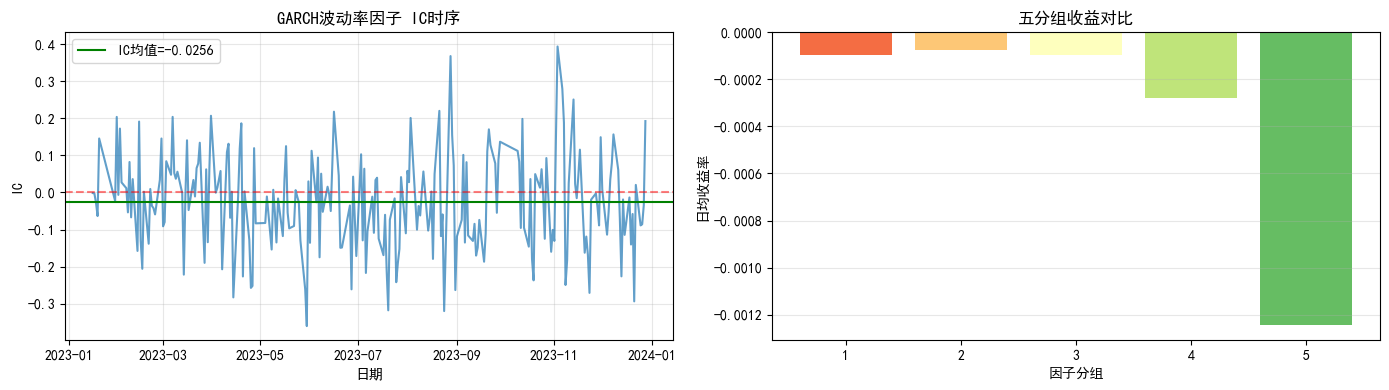

In [10]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ic_series.index, ic_series.values, alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].axhline(y=ic_mean, color='g', linestyle='-', label=f'IC均值={ic_mean:.4f}')
axes[0].set_title('GARCH波动率因子 IC时序', fontsize=12)
axes[0].set_xlabel('日期')
axes[0].set_ylabel('IC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

groups = quintile_result.index.tolist()
returns = quintile_result.values
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(groups)))
axes[1].bar(groups, returns, color=colors)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('五分组收益对比', fontsize=12)
axes[1].set_xlabel('因子分组')
axes[1].set_ylabel('日均收益率')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 步骤三：GARCH单因子多空策略回测

In [11]:
# 1. 设置回测参数
transaction_cost = 0.0003

def long_short_strategy(daily_data, top_pct=0.1, bottom_pct=0.1):
    data = daily_data.copy()
    n = len(data)
    data['rank'] = data['garch_vol_zscore'].rank(ascending=False)
    short_threshold = n * top_pct
    long_threshold = n * (1 - bottom_pct)
    data['position'] = 0
    data.loc[data['rank'] <= short_threshold, 'position'] = -1
    data.loc[data['rank'] >= long_threshold, 'position'] = 1
    return data

strategy_returns = []
prev_positions = {}  # 存储前一天的仓位
dates_sorted = sorted(df_analysis['date'].unique())

for i, date in enumerate(dates_sorted[:-1]):
    current_data = df_analysis[df_analysis['date'] == date].copy()
    if len(current_data) < 10:
        continue
    position_data = long_short_strategy(current_data)
    next_date = dates_sorted[i + 1]
    next_data = df_analysis[df_analysis['date'] == next_date][['asset', 'return_forward']].rename(columns={'return_forward': 'next_return'})
    position_data = position_data.merge(next_data, on='asset', how='left')
    position_data['position_pnl'] = position_data['position'] * position_data['next_return']
    
    # 计算换手率：对比当前仓位和前一天仓位
    if i > 0 and prev_positions:
        position_data['prev_position'] = position_data['asset'].map(prev_positions).fillna(0)
        position_data['turnover'] = (position_data['position'] != position_data['prev_position']).astype(float) * 0.5
    else:
        position_data['turnover'] = (position_data['position'] != 0).astype(float) * 0.5
    
    # 保存当前仓位供下一天使用
    prev_positions = dict(zip(position_data['asset'], position_data['position']))
    
    long_ret = position_data[position_data['position'] == 1]['next_return'].mean()
    short_ret = position_data[position_data['position'] == -1]['next_return'].mean()
    ls_ret = position_data[position_data['position'] != 0]['position_pnl'].mean()
    n_positions = (position_data['position'] != 0).sum()
    turnover = position_data['turnover'].sum() / max(n_positions, 1)
    cost = turnover * transaction_cost
    net_return = ls_ret - cost * 2
    
    strategy_returns.append({
        'date': date,
        'long_return': long_ret,
        'short_return': short_ret,
        'ls_return': net_return,
        'turnover': turnover
    })

strategy_df = pd.DataFrame(strategy_returns)
print(f"回测日期量: {len(strategy_df)}")

回测日期量: 231


In [12]:
# 2. 计算策略绩效指标
def calculate_performance_metrics(returns, risk_free_rate=0.03):
    returns = returns.dropna()
    annual_return = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = (annual_return - risk_free_rate) / annual_vol if annual_vol > 0 else np.nan
    win_rate = (returns > 0).mean()
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    avg_turnover = returns.abs().mean()
    return {
        'annual_return': annual_return,
        'annual_vol': annual_vol,
        'sharpe': sharpe,
        'win_rate': win_rate,
        'max_drawdown': max_drawdown,
        'avg_turnover': avg_turnover
    }

garch_metrics = calculate_performance_metrics(strategy_df['ls_return'])

print("▶ GARCH策略回测结果:")
print(f"   年化收益率: {garch_metrics['annual_return']:.2%}")
print(f"   年化波动率: {garch_metrics['annual_vol']:.2%}")
print(f"   夏普率: {garch_metrics['sharpe']:.3f}")
print(f"   胜率: {garch_metrics['win_rate']:.2%}")
print(f"   最大回撤: {garch_metrics['max_drawdown']:.2%}")
print(f"   平均换手率: {garch_metrics['avg_turnover']:.2%}")

▶ GARCH策略回测结果:
   年化收益率: 20.93%
   年化波动率: 10.96%
   夏普率: 1.637
   胜率: 52.81%
   最大回撤: -6.46%
   平均换手率: 0.54%


In [13]:
# 3. 对标沪深300
df_hs300_sorted = df_hs300.sort_values('date').copy()
df_hs300_sorted['hs300_return'] = np.log(df_hs300_sorted['close'] / df_hs300_sorted['close'].shift(1))
df_hs300_sorted = df_hs300_sorted.dropna(subset=['hs300_return'])

strategy_df = strategy_df.merge(df_hs300_sorted[['date', 'hs300_return']], on='date', how='left')
hs300_metrics = calculate_performance_metrics(strategy_df['hs300_return'].dropna())

print("\n▶ 沪深300基准绩效:")
print(f"   年化收益率: {hs300_metrics['annual_return']:.2%}")
print(f"   年化波动率: {hs300_metrics['annual_vol']:.2%}")
print(f"   夏普率: {hs300_metrics['sharpe']:.3f}")
print(f"   最大回撤: {hs300_metrics['max_drawdown']:.2%}")


▶ 沪深300基准绩效:
   年化收益率: -21.80%
   年化波动率: 13.26%
   夏普率: -1.870
   最大回撤: -22.13%


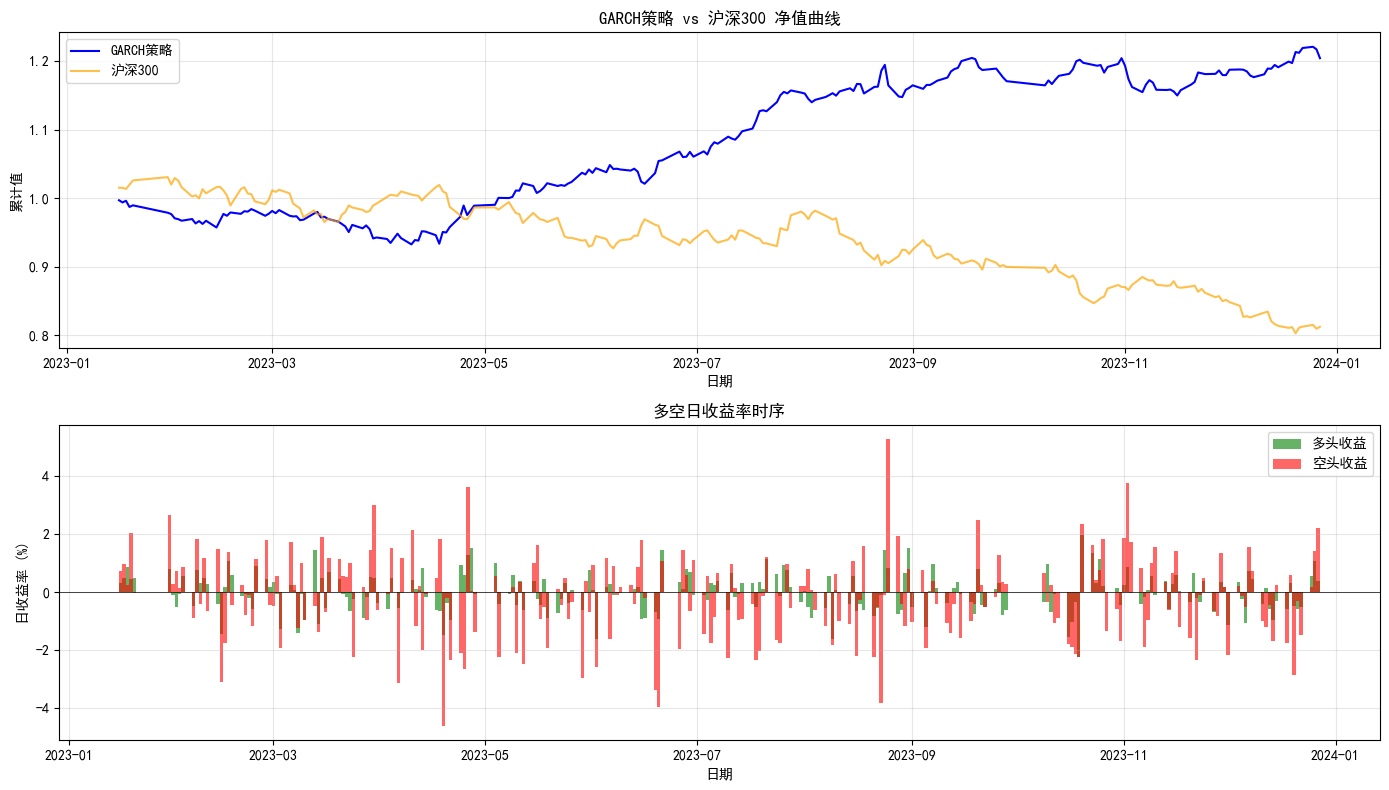

In [14]:
# 4. 可视化
strategy_df_plot = strategy_df.dropna(subset=['ls_return', 'hs300_return']).copy()
strategy_df_plot['strategy_cum'] = (1 + strategy_df_plot['ls_return']).cumprod()
strategy_df_plot['hs300_cum'] = (1 + strategy_df_plot['hs300_return']).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(strategy_df_plot['date'], strategy_df_plot['strategy_cum'], label='GARCH策略', color='blue', linewidth=1.5)
axes[0].plot(strategy_df_plot['date'], strategy_df_plot['hs300_cum'], label='沪深300', color='orange', linewidth=1.5, alpha=0.7)
axes[0].set_title('GARCH策略 vs 沪深300 净值曲线', fontsize=12)
axes[0].set_xlabel('日期')
axes[0].set_ylabel('累计值')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(strategy_df_plot['date'], strategy_df_plot['long_return'] * 100, alpha=0.6, label='多头收益', color='green', width=1)
axes[1].bar(strategy_df_plot['date'], strategy_df_plot['short_return'] * 100, alpha=0.6, label='空头收益', color='red', width=1)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('多空日收益率时序', fontsize=12)
axes[1].set_xlabel('日期')
axes[1].set_ylabel('日收益率 (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


▶ 五个因子相关系数矩阵:
          GARCH波动率   20日量比     成交额     笔均量    价格振幅
GARCH波动率    1.0000  0.0414  0.2847 -0.0153  0.4526
20日量比       0.0414  1.0000  0.3138  0.1536  0.5509
成交额         0.2847  0.3138  1.0000  0.3072  0.4350
笔均量        -0.0153  0.1536  0.3072  1.0000  0.0376
价格振幅        0.4526  0.5509  0.4350  0.0376  1.0000


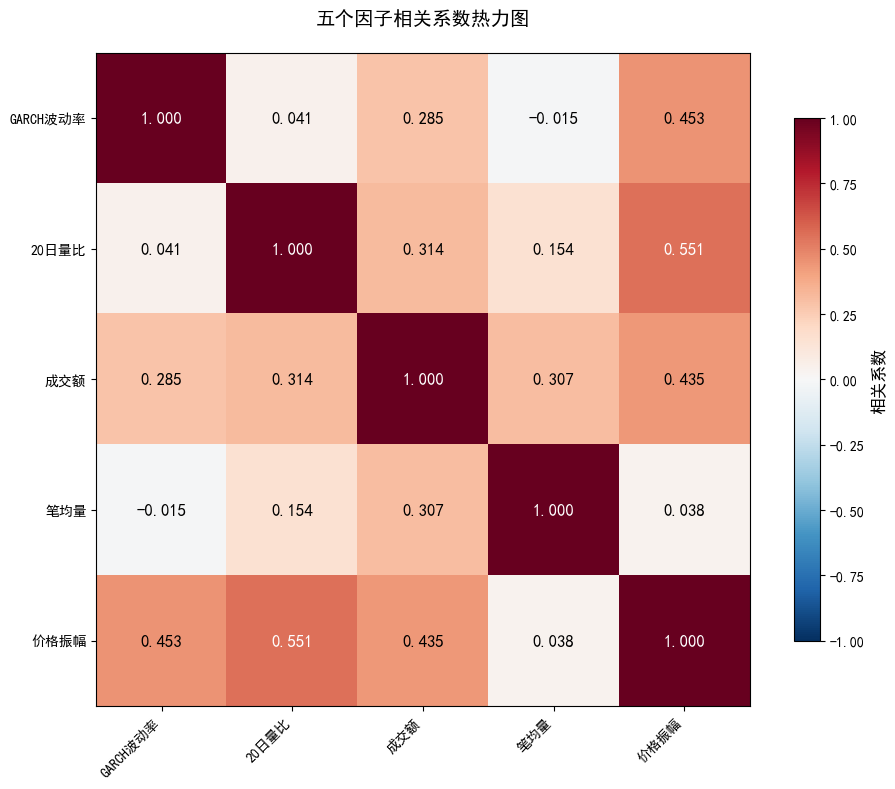


▶ 高相关性因子对 (|r| > 0.5):
   20日量比 - 价格振幅: 0.5509


In [15]:
# 因子相关性分析
factor_names = ["vol_rolling_std", "volume_ratio", "amount_scaled", "avg_trade_size_scaled", "price_amplitude"]
factor_labels = ["GARCH波动率", "20日量比", "成交额", "笔均量", "价格振幅"]

# 计算五个因子的相关系数矩阵
correlation_matrix = df_analysis[factor_names].corr()
correlation_matrix.index = factor_labels
correlation_matrix.columns = factor_labels

print("▶ 五个因子相关系数矩阵:")
print(correlation_matrix.round(4))

# 绘制热力图
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(factor_labels)))
ax.set_yticks(np.arange(len(factor_labels)))
ax.set_xticklabels(factor_labels, rotation=45, ha="right")
ax.set_yticklabels(factor_labels)

for i in range(len(factor_labels)):
    for j in range(len(factor_labels)):
        val = correlation_matrix.iloc[i, j]
        text_color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color=text_color, fontsize=12, fontweight="bold")

ax.set_title("五个因子相关系数热力图", fontsize=14, fontweight="bold", pad=20)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("相关系数", fontsize=12)

plt.tight_layout()
plt.show()

# 输出高相关性因子对
print("\n▶ 高相关性因子对 (|r| > 0.5):")
high_corr_pairs = []
for i in range(len(factor_labels)):
    for j in range(i+1, len(factor_labels)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            high_corr_pairs.append((factor_labels[i], factor_labels[j], corr_val))

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"   {pair[0]} - {pair[1]}: {pair[2]:.4f}")
else:
    print("   无高相关性因子对")


## 步骤四：多因子PCA主成分合成

In [16]:
# 1. 5个因子截面Z-score标准化
def cross_section_zscore(group):
    return group.sub(group.mean()).div(group.std() + 1e-8)

factor_cols = ['vol_rolling_std', 'volume_ratio', 'amount_scaled', 'avg_trade_size_scaled', 'price_amplitude']

df_pca = df_analysis.copy()
for col in factor_cols:
    df_pca[col + '_zscore'] = df_pca.groupby('date')[col].transform(cross_section_zscore)

zscore_cols = [col + '_zscore' for col in factor_cols]
print("5个因子截面Z-score标准化完成")
df_pca[zscore_cols].describe()

5个因子截面Z-score标准化完成


,vol_rolling_std_zscore,volume_ratio_zscore,amount_scaled_zscore,avg_trade_size_scaled_zscore,price_amplitude_zscore
count,1.159888e+06,1.159888e+06,1.159888e+06,1.159888e+06,1.159888e+06
mean,-1.058566e-17,-1.097772e-17,-6.106357e-17,5.136005e-17,-1.646658e-17
std,9.998997e-01,9.999004e-01,9.999004e-01,9.999004e-01,9.998999e-01
min,-1.654064e+00,-2.179149e+00,-1.653645e+01,-9.246026e+00,-2.666469e+00
25%,-5.810273e-01,-5.390904e-01,-6.304309e-01,-6.726373e-01,-6.160509e-01
50%,-2.456094e-01,-2.401731e-01,-7.357610e-02,-1.258975e-01,-2.703658e-01
75%,2.993140e-01,2.029963e-01,5.792196e-01,5.290955e-01,2.819895e-01
max,4.968837e+01,2.827989e+01,5.035124e+00,5.998005e+00,5.204766e+01


In [17]:
# 2. PCA分析与主成分解释率
pca_results = []
dates_pca = sorted(df_pca['date'].unique())

for date in dates_pca:
    daily_data = df_pca[df_pca['date'] == date][zscore_cols].dropna()
    if len(daily_data) < 10:
        continue
    try:
        pca = PCA(n_components=min(5, len(zscore_cols)))
        pca.fit(daily_data)
        pca_results.append({
            'date': date,
            'explained_variance_ratio': pca.explained_variance_ratio_,
            'cumsum': np.cumsum(pca.explained_variance_ratio_)
        })
    except:
        pass

components_list = []
for r in pca_results:
    for i, ratio in enumerate(r['explained_variance_ratio']):
        components_list.append({'PC': f'PC{i+1}', 'explained_variance_ratio': ratio})

components_df = pd.DataFrame(components_list)
avg_explained = components_df.groupby('PC')['explained_variance_ratio'].mean()

print("\n▶ PCA主成分解释率 (平均值):")
for pc, ratio in avg_explained.items():
    print(f"   {pc}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"   累计解释率: {avg_explained.cumsum().values}")


▶ PCA主成分解释率 (平均值):
   PC1: 0.4360 (43.60%)
   PC2: 0.2248 (22.48%)
   PC3: 0.1816 (18.16%)
   PC4: 0.1054 (10.54%)
   PC5: 0.0522 (5.22%)
   累计解释率: [0.43602505 0.66081768 0.84241223 0.94778315 1.        ]


In [18]:
# 3. 筛选累计方差解释率90%及以上的主成分
cumsum_ratios = avg_explained.cumsum()
n_components_90 = (cumsum_ratios >= 0.90).idxmax()
n_components_idx = list(cumsum_ratios.index).index(n_components_90) + 1

print(f"▶ 筛选结果:")
print(f"   累计方差解释率 ≥90% 需要的主成分数: {n_components_idx}")
print(f"   前{n_components_idx}个主成分累计解释率: {cumsum_ratios.iloc[n_components_idx-1]:.4f}")

▶ 筛选结果:
   累计方差解释率 ≥90% 需要的主成分数: 4
   前4个主成分累计解释率: 0.9478


In [19]:
# 4. 合成综合选股因子
def calculate_pca_factor(daily_data, n_components=2):
    pca = PCA(n_components=n_components)
    factors = pca.fit_transform(daily_data)
    pca_factor = factors[:, 0]
    return pca_factor, pca.explained_variance_ratio_

pca_factor_results = []

for date in dates_pca:
    daily_data = df_pca[df_pca['date'] == date][zscore_cols].dropna()
    assets = df_pca[df_pca['date'] == date][zscore_cols].dropna().index
    if len(daily_data) < 10:
        continue
    try:
        pca_factor, explained_ratio = calculate_pca_factor(daily_data, n_components=2)
        temp_df = pd.DataFrame({'index': assets, 'pca_factor': pca_factor})
        temp_df['date'] = date
        pca_factor_results.append(temp_df)
    except:
        pass

pca_factor_df = pd.concat(pca_factor_results, ignore_index=True)
df_pca = df_pca.reset_index(drop=True)
df_pca['pca_factor'] = df_pca.index.map(pca_factor_df.set_index('index')['pca_factor'].to_dict())

print("PCA合成因子计算完成")

PCA合成因子计算完成


In [20]:
# 5. 计算合成因子IC、IR与五分组检验
df_pca_analysis = df_pca.dropna(subset=['pca_factor', 'return_forward']).copy()
df_pca_analysis['pca_factor_zscore'] = df_pca_analysis.groupby('date')['pca_factor'].transform(cross_section_zscore)

pca_ic_series = df_pca_analysis.groupby('date').apply(
    lambda x: x['pca_factor_zscore'].corr(x['return_forward'])
)
pca_ic_mean = pca_ic_series.mean()
pca_ic_std = pca_ic_series.std()
pca_ir = pca_ic_mean / pca_ic_std if pca_ic_std > 0 else np.nan

print(f"▶ PCA因子 IC分析:")
print(f"   IC均值: {pca_ic_mean:.4f}")
print(f"   IC标准差: {pca_ic_std:.4f}")
print(f"   IR: {pca_ir:.4f}")
print(f"   IC正率: {(pca_ic_series>0).mean():.2%}")

pca_quintile, pca_spread = quintile_test(df_pca_analysis['pca_factor_zscore'], df_pca_analysis['return_forward'])

print(f"\n▶ PCA因子 五分组检验:")
for idx, ret in pca_quintile.items():
    print(f"   组{idx}: 日均收益 {ret:.4%}")
print(f"   增序等差 (Q5-Q1): {pca_spread:.4%}")

▶ PCA因子 IC分析:
   IC均值: -0.0324
   IC标准差: 0.1194
   IR: -0.2710
   IC正率: 37.93%

▶ PCA因子 五分组检验:
   组1: 日均收益 0.0151%
   组2: 日均收益 -0.0070%
   组3: 日均收益 -0.0194%
   组4: 日均收益 -0.0234%
   组5: 日均收益 -0.1467%
   增序等差 (Q5-Q1): -0.1618%


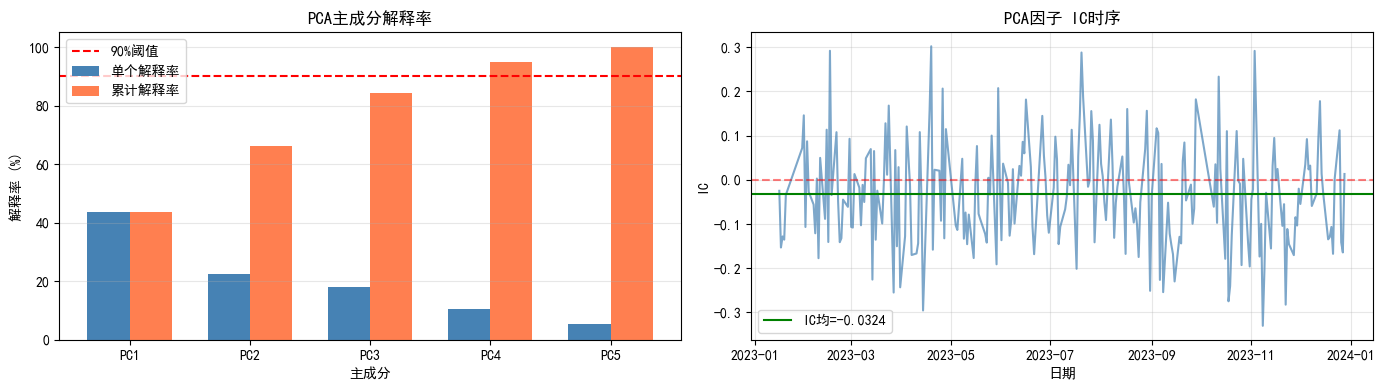

In [21]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pc_labels = avg_explained.index.tolist()
explained_vals = avg_explained.values * 100
cumsum_vals = avg_explained.cumsum().values * 100

x = np.arange(len(pc_labels))
width = 0.35
axes[0].bar(x - width/2, explained_vals, width, label='单个解释率', color='steelblue')
axes[0].bar(x + width/2, cumsum_vals, width, label='累计解释率', color='coral')
axes[0].axhline(y=90, color='red', linestyle='--', label='90%阈值')
axes[0].set_xlabel('主成分')
axes[0].set_ylabel('解释率 (%)')
axes[0].set_title('PCA主成分解释率')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pc_labels)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(pca_ic_series.index, pca_ic_series.values, alpha=0.7, color='steelblue')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].axhline(y=pca_ic_mean, color='g', linestyle='-', label=f'IC均={pca_ic_mean:.4f}')
axes[1].set_title('PCA因子 IC时序', fontsize=12)
axes[1].set_xlabel('日期')
axes[1].set_ylabel('IC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 步骤五：PCA合成因子多空策略回测

In [22]:
# 1. PCA策略回测执行
pca_strategy_returns = []
pca_prev_positions = {}  # 存储前一天的仓位

for i, date in enumerate(dates_sorted[:-1]):
    current_data = df_pca_analysis[df_pca_analysis['date'] == date].copy()
    if len(current_data) < 10:
        continue
    current_data['rank'] = current_data['pca_factor_zscore'].rank(ascending=False)
    n = len(current_data)
    short_threshold = n * 0.1
    long_threshold = n * 0.9
    current_data['position'] = 0
    current_data.loc[current_data['rank'] <= short_threshold, 'position'] = -1
    current_data.loc[current_data['rank'] >= long_threshold, 'position'] = 1
    
    next_date = dates_sorted[i + 1]
    next_data = df_pca_analysis[df_pca_analysis['date'] == next_date][['asset', 'return_forward']].rename(columns={'return_forward': 'next_return'})
    current_data = current_data.merge(next_data, on='asset', how='left')
    current_data['position_pnl'] = current_data['position'] * current_data['next_return']
    
    # 计算换手率
    if i > 0 and pca_prev_positions:
        current_data['prev_position'] = current_data['asset'].map(pca_prev_positions).fillna(0)
        current_data['turnover'] = (current_data['position'] != current_data['prev_position']).astype(float) * 0.5
    else:
        current_data['turnover'] = (current_data['position'] != 0).astype(float) * 0.5
    
    # 保存当前仓位供下一天使用
    pca_prev_positions = dict(zip(current_data['asset'], current_data['position']))
    
    long_ret = current_data[current_data['position'] == 1]['next_return'].mean()
    short_ret = current_data[current_data['position'] == -1]['next_return'].mean()
    ls_ret = current_data[current_data['position'] != 0]['position_pnl'].mean()
    n_positions = (current_data['position'] != 0).sum()
    turnover = current_data['turnover'].sum() / max(n_positions, 1)
    cost = turnover * transaction_cost
    net_return = ls_ret - cost * 2
    
    pca_strategy_returns.append({
        'date': date,
        'long_return': long_ret,
        'short_return': short_ret,
        'ls_return': net_return,
        'turnover': turnover
    })

pca_strategy_df = pd.DataFrame(pca_strategy_returns)
print(f"PCA策略回测日期量: {len(pca_strategy_df)}")

PCA策略回测日期量: 231


In [23]:
# 2. PCA策略绩效计算
pca_metrics = calculate_performance_metrics(pca_strategy_df['ls_return'])

print("▶ PCA合成因子策略回测结果:")
print(f"   年化收益率: {pca_metrics['annual_return']:.2%}")
print(f"   年化波动率: {pca_metrics['annual_vol']:.2%}")
print(f"   夏普率: {pca_metrics['sharpe']:.3f}")
print(f"   胜率: {pca_metrics['win_rate']:.2%}")
print(f"   最大回撤: {pca_metrics['max_drawdown']:.2%}")
print(f"   平均换手率: {pca_metrics['avg_turnover']:.2%}")

▶ PCA合成因子策略回测结果:
   年化收益率: 8.33%
   年化波动率: 8.38%
   夏普率: 0.636
   胜率: 49.78%
   最大回撤: -5.52%
   平均换手率: 0.42%


In [24]:
# 3. 全面对标沪深300基准
pca_strategy_df = pca_strategy_df.merge(df_hs300_sorted[['date', 'hs300_return']], on='date', how='left')

performance_comparison = pd.DataFrame({
    '指标': ['年化收益率', '年化波动率', '夏普率', '胜率', '最大回撤'],
    'GARCH策略': [f"{garch_metrics['annual_return']:.2%}", f"{garch_metrics['annual_vol']:.2%}", 
                 f"{garch_metrics['sharpe']:.3f}", f"{garch_metrics['win_rate']:.2%}", 
                 f"{garch_metrics['max_drawdown']:.2%}"],
    'PCA策略': [f"{pca_metrics['annual_return']:.2%}", f"{pca_metrics['annual_vol']:.2%}",
               f"{pca_metrics['sharpe']:.3f}", f"{pca_metrics['win_rate']:.2%}",
               f"{pca_metrics['max_drawdown']:.2%}"],
    '沪深300': [f"{hs300_metrics['annual_return']:.2%}", f"{hs300_metrics['annual_vol']:.2%}",
                f"{hs300_metrics['sharpe']:.3f}", f"{hs300_metrics['win_rate']:.2%}",
                f"{hs300_metrics['max_drawdown']:.2%}"]
})

print("\n▶ 策略绩效对比表:")
performance_comparison


▶ 策略绩效对比表:


,指标,GARCH策略,PCA策略,沪深300
0,年化收益率,20.93%,8.33%,-21.80%
1,年化波动率,10.96%,8.38%,13.26%
2,夏普率,1.637,0.636,-1.870
3,胜率,52.81%,49.78%,41.99%
4,最大回撤,-6.46%,-5.52%,-22.13%


In [25]:
returns_series = pca_strategy_df['ls_return'].dropna().values
confidence_levels = [0.95, 0.99]

print(f"收益率序列长度: {len(returns_series)}")
print(f"收益率均值: {returns_series.mean():.4%}")
print(f"收益率标准差: {returns_series.std():.4%}")

收益率序列长度: 231
收益率均值: 0.0330%
收益率标准差: 0.5265%


## 步骤六：高斯Copula尾部相关性建模

In [26]:
# 1. 提取PCA策略的多头、空头收益率序列
long_returns_pca = pca_strategy_df['long_return'].dropna().values
short_returns_pca = pca_strategy_df['short_return'].dropna().values

print(f"多头收益率序列长度: {len(long_returns_pca)}")
print(f"空头收益率序列长度: {len(short_returns_pca)}")

多头收益率序列长度: 231
空头收益率序列长度: 231


In [27]:
# 2. 拟合经验分布、概率积分变换
def probability_integral_transform(data):
    n = len(data)
    ranks = stats.rankdata(data, method='average')
    pit = (ranks - 0.5) / n
    return pit

long_pit = probability_integral_transform(long_returns_pca)
short_pit = probability_integral_transform(short_returns_pca)

print("概率积分变换完成")
print(f"Long PIT - Mean: {long_pit.mean():.4f}, Std: {long_pit.std():.4f}")
print(f"Short PIT - Mean: {short_pit.mean():.4f}, Std: {short_pit.std():.4f}")

概率积分变换完成
Long PIT - Mean: 0.5000, Std: 0.2887
Short PIT - Mean: 0.5000, Std: 0.2887


In [28]:
# 3. 估计高斯Copula相关系数
def estimate_gaussian_copula_correlation(u, v):
    u_normal = norm.ppf(u)
    v_normal = norm.ppf(v)
    rho = np.corrcoef(u_normal, v_normal)[0, 1]
    return rho

copula_rho = estimate_gaussian_copula_correlation(long_pit, short_pit)

print(f"▶ 高斯Copula相关系数: {copula_rho:.4f}")

▶ 高斯Copula相关系数: 0.5773


In [29]:
# 4. 计算尾部相关系数
def calculate_tail_dependence(u, v, tail_level=0.05):
    n = len(u)
    q = tail_level
    left_tail_joint = ((u <= q) & (v <= q)).sum() / n
    lambda_lower = left_tail_joint / q if q > 0 else 0
    right_tail_joint = ((u >= 1-q) & (v >= 1-q)).sum() / n
    lambda_upper = right_tail_joint / q if q > 0 else 0
    lambda_lower = min(max(lambda_lower, 0), 1)
    lambda_upper = min(max(lambda_upper, 0), 1)
    return lambda_lower, lambda_upper

tail_levels = [0.05, 0.10, 0.15]
tail_dependence_results = []

for level in tail_levels:
    lambda_lower, lambda_upper = calculate_tail_dependence(long_pit, short_pit, level)
    tail_dependence_results.append({
        'tail_level': level,
        'left_tail_dependence': lambda_lower,
        'right_tail_dependence': lambda_upper
    })

tail_df = pd.DataFrame(tail_dependence_results)

print("\n▶ 尾部相关性分析:")
print(tail_df.to_string(index=False))


▶ 尾部相关性分析:
 tail_level  left_tail_dependence  right_tail_dependence
       0.05               0.17316                0.25974
       0.10               0.30303                0.38961
       0.15               0.46176                0.40404


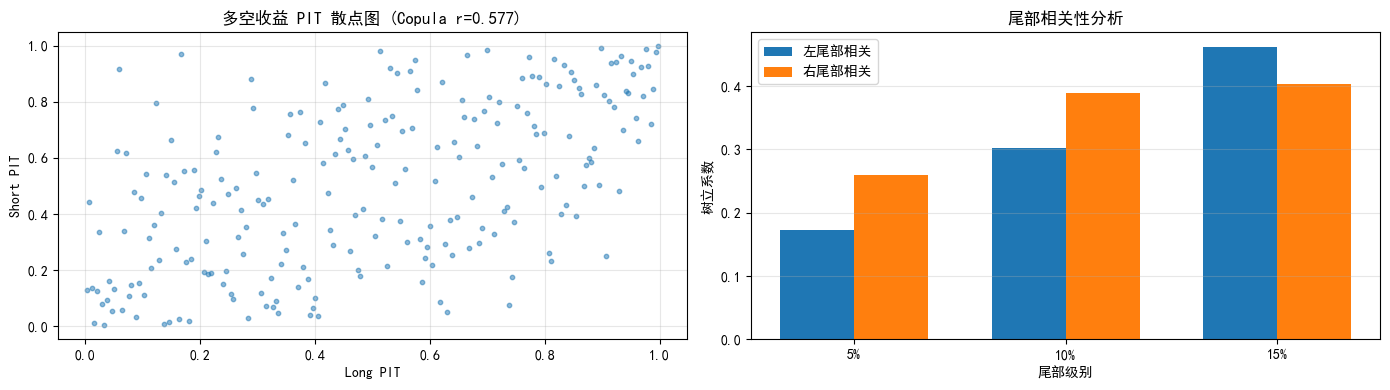

In [30]:
# 5. 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(long_pit, short_pit, alpha=0.5, s=10)
axes[0].set_xlabel('Long PIT')
axes[0].set_ylabel('Short PIT')
axes[0].set_title(f'多空收益 PIT 散点图 (Copula r={copula_rho:.3f})')
axes[0].grid(True, alpha=0.3)

x = np.arange(len(tail_levels))
width = 0.35
axes[1].bar(x - width/2, tail_df['left_tail_dependence'], width, label='左尾部相关')
axes[1].bar(x + width/2, tail_df['right_tail_dependence'], width, label='右尾部相关')
axes[1].set_xlabel('尾部级别')
axes[1].set_ylabel('树立系数')
axes[1].set_title('尾部相关性分析')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{l:.0%}' for l in tail_levels])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 步骤七：四类方法VaR/ES风险计量

In [31]:
returns_series = pca_strategy_df['ls_return'].dropna().values
confidence_levels = [0.95, 0.99]

print(f"收益率序列长度: {len(returns_series)}")
print(f"收益率均值: {returns_series.mean():.4%}")
print(f"收益率标准差: {returns_series.std():.4%}")

收益率序列长度: 231
收益率均值: 0.0330%
收益率标准差: 0.5265%


In [32]:
from scipy.stats import norm, genpareto, skew, kurtosis

def parametric_var_es(returns, confidence_level):
    mu, sigma = returns.mean(), returns.std()
    z = norm.ppf(1 - confidence_level)
    var = mu + sigma * z
    es = mu - sigma * norm.pdf(z) / (1 - confidence_level)
    return var, es

def historical_simulation_var_es(returns, confidence_level):
    var = np.percentile(returns, (1 - confidence_level) * 100)
    tail_losses = returns[returns <= var]
    es = tail_losses.mean() if len(tail_losses) > 0 else var
    return var, es

def gpd_tail_correction(returns, confidence_level, tail_percentile=0.10):
    threshold = np.percentile(returns, tail_percentile * 100)
    excess_losses = threshold - returns[returns <= threshold]
    
    if len(excess_losses) < 10:
        return historical_simulation_var_es(returns, confidence_level)
    
    try:
        shape, loc, scale = genpareto.fit(excess_losses, floc=0)
        n_total, n_tail = len(returns), len(excess_losses)
        p_tail = n_tail / n_total
        p_exceed = (1 - confidence_level) / p_tail
        
        if abs(shape) < 1e-10:
            var_excess = scale * np.log(1 / p_exceed)
        else:
            var_excess = (scale / shape) * ((p_exceed) ** (-shape) - 1)
        
        var_gpd = threshold - var_excess
        es_gpd = var_gpd - (scale - shape * var_excess) / (1 - shape) if shape < 1 else var_gpd
        return var_gpd, es_gpd
    except:
        return historical_simulation_var_es(returns, confidence_level)

def monte_carlo_var_es(returns, confidence_level, n_simulations=10000):
    mu, sigma = returns.mean(), returns.std()
    simulated = np.random.normal(mu, sigma, n_simulations)
    var = np.percentile(simulated, (1 - confidence_level) * 100)
    es = simulated[simulated <= var].mean()
    return var, es

def cornish_fisher_3rd_moment(returns, confidence_level):
    mu, sigma = returns.mean(), returns.std()
    s = skew(returns)
    z = norm.ppf(1 - confidence_level)
    z_cf = z + (z**2 - 1) * s / 6
    var = mu + sigma * z_cf
    es = mu - sigma * norm.pdf(z_cf) / (1 - confidence_level)
    return var, es

def cornish_fisher_expansion(returns, confidence_level):
    mu, sigma = returns.mean(), returns.std()
    s, k = skew(returns), kurtosis(returns)
    z = norm.ppf(1 - confidence_level)
    z_cf = z + (z**2 - 1) * s / 6 + (z**3 - 3*z) * (k - 3) / 24 - (2*z**3 - 5*z) * s**2 / 36
    var = mu + sigma * z_cf
    es = mu - sigma * norm.pdf(z_cf) / (1 - confidence_level)
    return var, es

print("VaR/ES计算函数定义完成")

VaR/ES计算函数定义完成


In [33]:
var_es_results = []

for cl in confidence_levels:
    var_es_results.append({'confidence_level': cl, 'method': '参数法', 'VaR': parametric_var_es(returns_series, cl)[0], 'ES': parametric_var_es(returns_series, cl)[1]})
    var_es_results.append({'confidence_level': cl, 'method': '历史模拟', 'VaR': historical_simulation_var_es(returns_series, cl)[0], 'ES': historical_simulation_var_es(returns_series, cl)[1]})
    var_es_results.append({'confidence_level': cl, 'method': 'GPD极值修正', 'VaR': gpd_tail_correction(returns_series, cl)[0], 'ES': gpd_tail_correction(returns_series, cl)[1]})
    var_es_results.append({'confidence_level': cl, 'method': '蒙特卡洛', 'VaR': monte_carlo_var_es(returns_series, cl)[0], 'ES': monte_carlo_var_es(returns_series, cl)[1]})
    var_es_results.append({'confidence_level': cl, 'method': '克尼斯费希尔-三阶矩', 'VaR': cornish_fisher_3rd_moment(returns_series, cl)[0], 'ES': cornish_fisher_3rd_moment(returns_series, cl)[1]})
    var_es_results.append({'confidence_level': cl, 'method': '克尼斯费希尔(三阶+四阶)', 'VaR': cornish_fisher_expansion(returns_series, cl)[0], 'ES': cornish_fisher_expansion(returns_series, cl)[1]})

var_es_df = pd.DataFrame(var_es_results)
var_es_df['VaR'] = var_es_df['VaR'].apply(lambda x: f"{x:.4%}")
var_es_df['ES'] = var_es_df['ES'].apply(lambda x: f"{x:.4%}")

print("▶ VaR/ES风险计量对比表:")
var_es_df

▶ VaR/ES风险计量对比表:


,confidence_level,method,VaR,ES
0,0.95,参数法,-0.8330%,-1.0531%
1,0.95,历史模拟,-0.7702%,-1.0887%
2,0.95,GPD极值修正,-0.8332%,-1.1999%
3,0.95,蒙特卡洛,-0.8388%,-1.0418%
4,0.95,克尼斯费希尔-三阶矩,-0.8358%,-1.0437%
5,0.95,克尼斯费希尔(三阶+四阶),-0.8676%,-0.9397%
6,0.99,参数法,-1.1919%,-1.3703%
7,0.99,历史模拟,-1.2747%,-1.4027%
8,0.99,GPD极值修正,-1.2384%,-1.7001%
9,0.99,蒙特卡洛,-1.1897%,-1.3618%


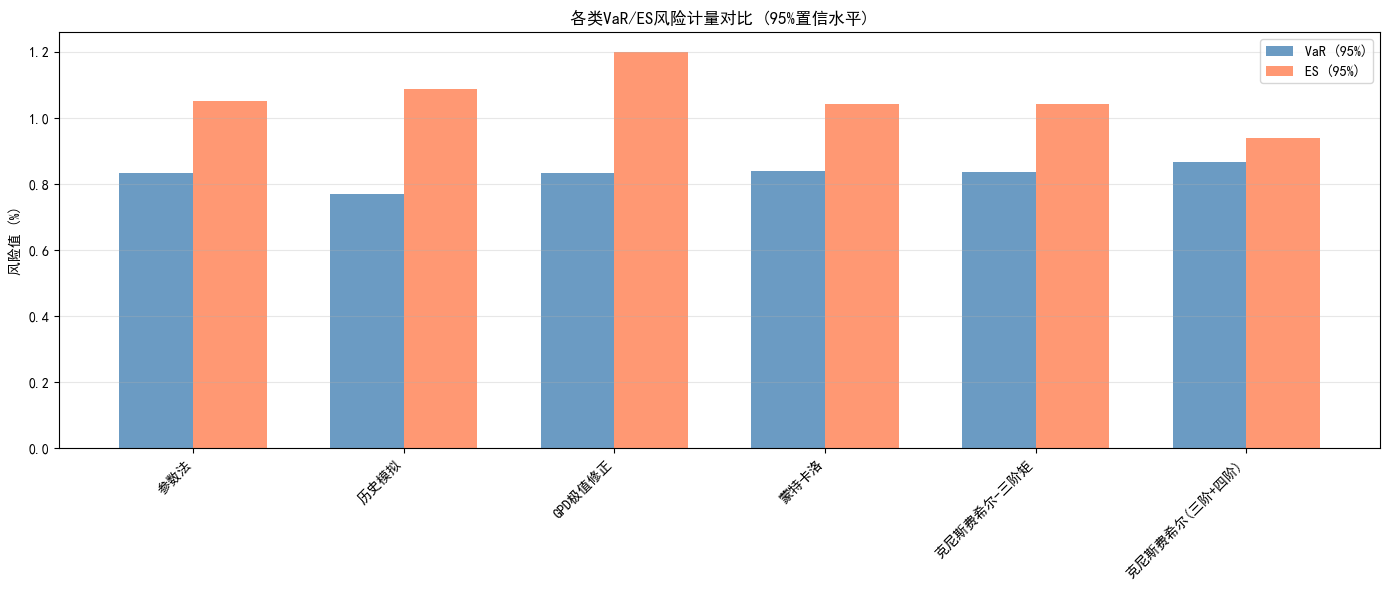

In [34]:
fig, ax = plt.subplots(figsize=(14, 6))

methods = ['参数法', '历史模拟', 'GPD极值修正', '蒙特卡洛', '克尼斯费希尔-三阶矩', '克尼斯费希尔(三阶+四阶)']
x = np.arange(len(methods))
width = 0.35

var_95 = [-float(var_es_df[(var_es_df['confidence_level']==0.95)&(var_es_df['method']==m)]['VaR'].values[0].replace('%',''))/100 for m in methods]
es_95 = [-float(var_es_df[(var_es_df['confidence_level']==0.95)&(var_es_df['method']==m)]['ES'].values[0].replace('%',''))/100 for m in methods]

ax.bar(x - width/2, [v*100 for v in var_95], width, label='VaR (95%)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, [e*100 for e in es_95], width, label='ES (95%)', color='coral', alpha=0.8)

ax.set_ylabel('风险值 (%)')
ax.set_title('各类VaR/ES风险计量对比 (95%置信水平)')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 步骤八：风险模型统计检验

In [35]:
# 1. Kupiec似然比检验
def kupiec_lr_test(returns, var, confidence_level):
    violations = (returns < var).sum()
    n = len(returns)
    expected_violations = n * (1 - confidence_level)
    actual_rate = violations / n
    if actual_rate > 0 and actual_rate < 1:
        lr = -2 * (violations * np.log(actual_rate) + (n - violations) * np.log(1 - actual_rate) -
                   violations * np.log(1 - confidence_level) - (n - violations) * np.log(confidence_level))
    else:
        lr = 0
    p_value = 1 - stats.chi2.cdf(lr, df=1)
    return {
        'violations': violations,
        'expected_violations': expected_violations,
        'actual_rate': actual_rate,
        'lr_stat': lr,
        'p_value': p_value,
        'reject_h0': p_value < 0.05
    }

print("Kupiec LR检验函数定义完成")

Kupiec LR检验函数定义完成


In [36]:
# 2. Christoffersen方法检验VaR突破聚束状态
def christoffersen_test(returns, var):
    violations = (returns < var).astype(int)
    states = violations[:-1]
    next_states = violations[1:]
    pi_01 = (states == 0).sum()
    pi_11 = (states == 1).sum()
    pi_00 = ((states == 0) & (next_states == 0)).sum()
    pi_10 = ((states == 0) & (next_states == 1)).sum()
    pi_01_count = ((states == 1) & (next_states == 0)).sum()
    pi_11_count = ((states == 1) & (next_states == 1)).sum()
    try:
        p00 = pi_00 / pi_01 if pi_01 > 0 else 0
        p11 = pi_11_count / pi_11 if pi_11 > 0 else 0
        lr_ind = -2 * ((pi_00 + pi_11_count) * np.log(p00 if p00 > 0 else 0.5) + 
                       (pi_10 + pi_01_count) * np.log(1 - p00 if (1-p00) > 0 else 0.5) -
                       (pi_01 + pi_11_count) * np.log(0.5))
        p_value_ind = 1 - stats.chi2.cdf(lr_ind, df=1)
    except:
        lr_ind = np.nan
        p_value_ind = np.nan
    return {
        'lr_stat': lr_ind,
        'p_value': p_value_ind,
        'clustering': pi_11_count > 0
    }

print("Christoffersen方法函数定义完成")

Christoffersen方法函数定义完成


In [37]:
# 3. 输出全部检验结果表
test_results = []

for cl in confidence_levels:
    for method_name, var_func in [
        ('参数法', lambda r, c: parametric_var_es(r, c)[0]),
        ('历史模拟', lambda r, c: historical_simulation_var_es(r, c)[0]),
        ('GPD修正', lambda r, c: gpd_tail_correction(r, c)[0]),
        ('蒙特卡洛', lambda r, c: monte_carlo_var_es(r, c)[0]),
        ('克尼斯费希尔-三阶矩', lambda r, c: cornish_fisher_3rd_moment(r, c)[0]),
        ('克尼斯费希尔(三阶+四阶)', lambda r, c: cornish_fisher_expansion(r, c)[0])
    ]:
        var = var_func(returns_series, cl)
        kupiec_result = kupiec_lr_test(returns_series, var, cl)
        christ_result = christoffersen_test(returns_series, var)
        test_results.append({
            '置信水平': f"{cl:.0%}",
            '方法': method_name,
            'VaR': f"{var:.4%}",
            '突破次数': kupiec_result['violations'],
            '期望次数': f"{kupiec_result['expected_violations']:.1f}",
            'Kupiec_p值': f"{kupiec_result['p_value']:.4f}",
            'Kupiec结论': '拒绝H0' if kupiec_result['reject_h0'] else '接受H0',
            'Christ_p值': f"{christ_result['p_value']:.4f}" if not np.isnan(christ_result['p_value']) else 'N/A',
            '聚束': '是' if christ_result['clustering'] else '否'
        })

test_df = pd.DataFrame(test_results)

print("▶ 风险模型统计检验结果表:")
test_df

▶ 风险模型统计检验结果表:


,置信水平,方法,VaR,突破次数,期望次数,Kupiec_p值,Kupiec结论,Christ_p值,聚束
0,95%,参数法,-0.8330%,11,11.6,1.0000,接受H0,1.0000,是
1,95%,历史模拟,-0.7702%,12,11.6,1.0000,接受H0,1.0000,是
2,95%,GPD修正,-0.8332%,11,11.6,1.0000,接受H0,1.0000,是
3,95%,蒙特卡洛,-0.8327%,11,11.6,1.0000,接受H0,1.0000,是
4,95%,克尼斯费希尔-三阶矩,-0.8358%,11,11.6,1.0000,接受H0,1.0000,是
5,95%,克尼斯费希尔(三阶+四阶),-0.8676%,9,11.6,1.0000,接受H0,1.0000,否
6,99%,参数法,-1.1919%,3,2.3,1.0000,接受H0,1.0000,否
7,99%,历史模拟,-1.2747%,3,2.3,1.0000,接受H0,1.0000,否
8,99%,GPD修正,-1.2384%,3,2.3,1.0000,接受H0,1.0000,否
9,99%,蒙特卡洛,-1.1991%,3,2.3,1.0000,接受H0,1.0000,否


In [38]:
# 4. 计算VaR/ES标准误差
def bootstrap_std_error(returns, var_func, confidence_level, n_bootstrap=500):
    var_estimates = []
    n = len(returns)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        bootstrap_sample = returns[idx]
        try:
            var = var_func(bootstrap_sample, confidence_level)
            var_estimates.append(var)
        except:
            pass
    return np.std(var_estimates) if var_estimates else np.nan

std_error_results = []

for cl in confidence_levels:
    for method_name, var_func in [
        ('参数法', lambda r, c: parametric_var_es(r, c)[0]),
        ('历史模拟', lambda r, c: historical_simulation_var_es(r, c)[0]),
        ('GPD修正', lambda r, c: gpd_tail_correction(r, c)[0])
    ]:
        var_se = bootstrap_std_error(returns_series, var_func, cl)
        std_error_results.append({
            '置信水平': f"{cl:.0%}",
            '方法': method_name,
            'VaR标准误差': f"{var_se:.4%}" if not np.isnan(var_se) else 'N/A'
        })

std_error_df = pd.DataFrame(std_error_results)

print("\n▶ VaR标准误差表:")
std_error_df


▶ VaR标准误差表:


,置信水平,方法,VaR标准误差
0,95%,参数法,0.0540%
1,95%,历史模拟,0.1171%
2,95%,GPD修正,0.1550%
3,99%,参数法,0.0698%
4,99%,历史模拟,0.1378%
5,99%,GPD修正,0.1367%


## 步骤九：压力测试与反压力测试

In [39]:
# 1. 挑选2023年跌的最惨的情景
df_hs300_sorted['hs300_daily_return'] = df_hs300_sorted['hs300_return']
worst_days = df_hs300_sorted.nsmallest(4, 'hs300_daily_return')

print("▶ 2023年沪深300最差三日情景:\n")
print(worst_days[['date', 'close', 'hs300_daily_return']].to_string(index=False))

▶ 2023年沪深300最差三日情景:

      date   close  hs300_daily_return
2023-08-11 3884.25           -0.023276
2023-10-19 3533.54           -0.021568
2023-04-21 4032.57           -0.019754
2023-12-05 3394.26           -0.019223


In [40]:
# 2. 构建情景测试表
pca_strategy_df_stress = pca_strategy_df.merge(df_hs300_sorted[['date', 'hs300_daily_return']], on='date', how='left')

stress_scenarios = []
for _, row in worst_days.iterrows():
    stress_date = row['date']
    hs300_ret = row['hs300_daily_return']
    pca_ret = pca_strategy_df_stress[pca_strategy_df_stress['date'] == stress_date]['ls_return'].values
    pca_ret = pca_ret[0] if len(pca_ret) > 0 else np.nan
    stress_scenarios.append({
        '情景日期': stress_date.strftime('%Y-%m-%d'),
        '沪深300收益': f"{hs300_ret:.2%}",
        'PCA策略收益': f"{pca_ret:.2%}" if not np.isnan(pca_ret) else 'N/A'
    })

stress_df = pd.DataFrame(stress_scenarios)
print("▶ 压力测试情景表:")
stress_df

▶ 压力测试情景表:


,情景日期,沪深300收益,PCA策略收益
0,2023-08-11,-2.33%,0.10%
1,2023-10-19,-2.16%,-0.57%
2,2023-04-21,-1.98%,0.19%
3,2023-12-05,-1.92%,0.06%


In [41]:
# 3. 反压力测试：推导极端亏损触发情景
strategy_df_plot['drawdown'] = (strategy_df_plot['strategy_cum'] / strategy_df_plot['strategy_cum'].cummax()) - 1
max_dd_date = strategy_df_plot.loc[strategy_df_plot['drawdown'].idxmin(), 'date']
max_dd_value = strategy_df_plot['drawdown'].min()

max_dd_period = strategy_df_plot[strategy_df_plot['date'] >= max_dd_date].head(10)

print(f"▶ 最大回撤日期: {max_dd_date.strftime('%Y-%m-%d')}")
print(f"   最大回撤值: {max_dd_value:.2%}")
print(f"\n最大回撤时期环境:\n")
print(max_dd_period[['date', 'ls_return', 'hs300_return']].to_string(index=False))

▶ 最大回撤日期: 2023-04-10
   最大回撤值: -6.46%

最大回撤时期环境:

      date  ls_return  hs300_return
2023-04-10  -0.009783     -0.004490
2023-04-11   0.006787     -0.001136
2023-04-12  -0.000897     -0.000698
2023-04-13   0.014604     -0.006933
2023-04-14  -0.000461      0.005641
2023-04-17  -0.005591      0.013925
2023-04-18  -0.013153      0.003044
2023-04-19   0.018338     -0.009044
2023-04-20  -0.000733     -0.002802
2023-04-21   0.008254     -0.019754


In [42]:
returns_series = pca_strategy_df['ls_return'].dropna().values
confidence_levels = [0.95, 0.99]

print(f"收益率序列长度: {len(returns_series)}")
print(f"收益率均值: {returns_series.mean():.4%}")
print(f"收益率标准差: {returns_series.std():.4%}")

收益率序列长度: 231
收益率均值: 0.0330%
收益率标准差: 0.5265%


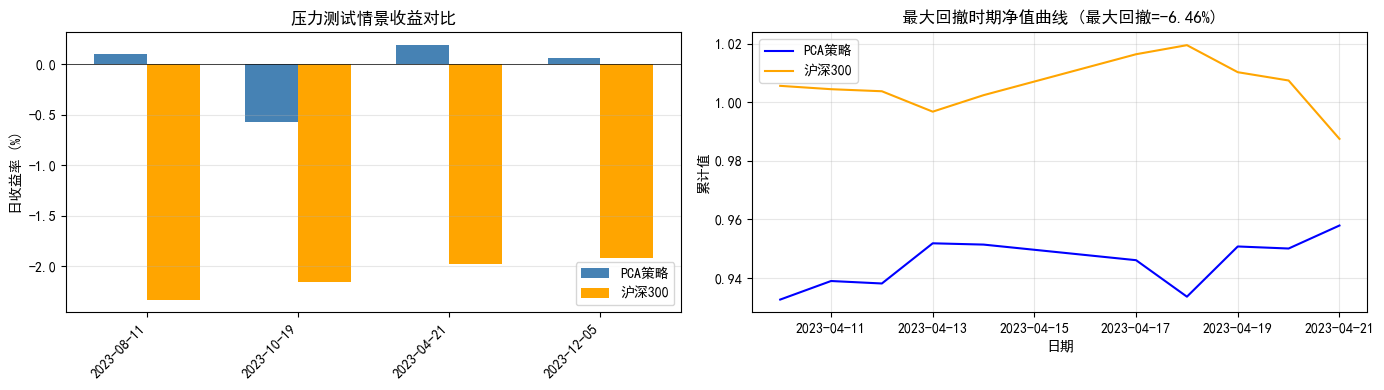

In [43]:
# 5. 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

stress_dates = [s['情景日期'] for s in stress_scenarios]
stress_pca_rets = []
for s in stress_scenarios:
    ret_str = s['PCA策略收益'].replace('%', '')
    stress_pca_rets.append(float(ret_str) / 100 if ret_str != 'N/A' else 0)

stress_hs300_rets = [float(s['沪深300收益'].replace('%', '')) / 100 for s in stress_scenarios]

x = np.arange(len(stress_dates))
width = 0.35
axes[0].bar(x - width/2, [r*100 for r in stress_pca_rets], width, label='PCA策略', color='steelblue')
axes[0].bar(x + width/2, [r*100 for r in stress_hs300_rets], width, label='沪深300', color='orange')
axes[0].set_ylabel('日收益率 (%)')
axes[0].set_title('压力测试情景收益对比')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stress_dates, rotation=45, ha='right')
axes[0].legend()
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(max_dd_period['date'], max_dd_period['strategy_cum'], label='PCA策略', color='blue')
axes[1].plot(max_dd_period['date'], max_dd_period['hs300_cum'], label='沪深300', color='orange')
axes[1].set_title(f'最大回撤时期净值曲线 (最大回撤={max_dd_value:.2%})')
axes[1].set_xlabel('日期')
axes[1].set_ylabel('累计值')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 步骤十：全维度结果汇总

In [44]:
# 1. 波动率对比表
vol_comparison = pd.DataFrame({
    '指标': ['年化波动率', '最大日收益', '最小日收益'],
    'GARCH策略': [
        f"{strategy_df['ls_return'].std() * np.sqrt(252):.2%}",
        f"{strategy_df['ls_return'].max():.2%}",
        f"{strategy_df['ls_return'].min():.2%}"
    ],
    'PCA策略': [
        f"{pca_strategy_df['ls_return'].std() * np.sqrt(252):.2%}",
        f"{pca_strategy_df['ls_return'].max():.2%}",
        f"{pca_strategy_df['ls_return'].min():.2%}"
    ],
    '沪深300': [
        f"{strategy_df['hs300_return'].std() * np.sqrt(252):.2%}",
        f"{strategy_df['hs300_return'].max():.2%}",
        f"{strategy_df['hs300_return'].min():.2%}"
    ]
})

print("▶ 1. 波动率对比表:")
print(vol_comparison.to_string(index=False))

▶ 1. 波动率对比表:
   指标 GARCH策略  PCA策略  沪深300
年化波动率  10.96%  8.38% 13.26%
最大日收益   2.02%  1.32%  2.85%
最小日收益  -2.50% -1.44% -2.33%


In [45]:
# 2. 单因子与PCA策略绩效对比表
final_performance = pd.DataFrame({
    '指标': ['年化收益率', '年化波动率', '夏普率', '胜率', '最大回撤'],
    'GARCH因子IC': [f"{ic_mean:.4f}", '-', f"{ir:.4f}", '-', '-'],
    'PCA因子IC': [f"{pca_ic_mean:.4f}", '-', f"{pca_ir:.4f}", '-', '-'],
    'GARCH策略': [f"{garch_metrics['annual_return']:.2%}", f"{garch_metrics['annual_vol']:.2%}",
                 f"{garch_metrics['sharpe']:.3f}", f"{garch_metrics['win_rate']:.2%}", 
                 f"{garch_metrics['max_drawdown']:.2%}"],
    'PCA策略': [f"{pca_metrics['annual_return']:.2%}", f"{pca_metrics['annual_vol']:.2%}",
               f"{pca_metrics['sharpe']:.3f}", f"{pca_metrics['win_rate']:.2%}",
               f"{pca_metrics['max_drawdown']:.2%}"],
    '沪深300': [f"{hs300_metrics['annual_return']:.2%}", f"{hs300_metrics['annual_vol']:.2%}",
                f"{hs300_metrics['sharpe']:.3f}", f"{hs300_metrics['win_rate']:.2%}",
                f"{hs300_metrics['max_drawdown']:.2%}"]
})

print("\n▶ 2. 单因子与PCA策略绩效对比表:")
final_performance


▶ 2. 单因子与PCA策略绩效对比表:


,指标,GARCH因子IC,PCA因子IC,GARCH策略,PCA策略,沪深300
0,年化收益率,-0.0256,-0.0324,20.93%,8.33%,-21.80%
1,年化波动率,-,-,10.96%,8.38%,13.26%
2,夏普率,-0.1966,-0.2710,1.637,0.636,-1.870
3,胜率,-,-,52.81%,49.78%,41.99%
4,最大回撤,-,-,-6.46%,-5.52%,-22.13%


In [46]:
# 3. Copula尾部特征表
copula_summary = pd.DataFrame({
    '指标': ['高斯Copula相关系数', '左尾部相关(5%)', '右尾部相关(5%)', '左尾部相关(10%)', '右尾部相关(10%)'],
    '数值': [
        f"{copula_rho:.4f}",
        f"{tail_df.iloc[0]['left_tail_dependence']:.4f}",
        f"{tail_df.iloc[0]['right_tail_dependence']:.4f}",
        f"{tail_df.iloc[1]['left_tail_dependence']:.4f}",
        f"{tail_df.iloc[1]['right_tail_dependence']:.4f}"
    ]
})

print("\n▶ 3. Copula尾部特征表:")
print(copula_summary.to_string(index=False))


▶ 3. Copula尾部特征表:
          指标     数值
高斯Copula相关系数 0.5773
   左尾部相关(5%) 0.1732
   右尾部相关(5%) 0.2597
  左尾部相关(10%) 0.3030
  右尾部相关(10%) 0.3896


In [47]:
# 4. 各类VaR模型效果表
var_summary = pd.DataFrame({
    '方法': ['参数法', '历史模拟', 'GPD极值修正', '蒙特卡洛', '克尼斯费希尔-三阶矩', '克尼斯费希尔(三阶+四阶)'],
    'VaR(95%)': [f"{parametric_var_es(returns_series, 0.95)[0]:.2%}", 
                 f"{historical_simulation_var_es(returns_series, 0.95)[0]:.2%}",
                 f"{gpd_tail_correction(returns_series, 0.95)[0]:.2%}",
                 f"{monte_carlo_var_es(returns_series, 0.95)[0]:.2%}",
                 f"{cornish_fisher_3rd_moment(returns_series, 0.95)[0]:.2%}",
                 f"{cornish_fisher_expansion(returns_series, 0.95)[0]:.2%}"],
    'ES(95%)': [f"{parametric_var_es(returns_series, 0.95)[1]:.2%}",
                f"{historical_simulation_var_es(returns_series, 0.95)[1]:.2%}",
                f"{gpd_tail_correction(returns_series, 0.95)[1]:.2%}",
                f"{monte_carlo_var_es(returns_series, 0.95)[1]:.2%}",
                f"{cornish_fisher_3rd_moment(returns_series, 0.95)[1]:.2%}",
                f"{cornish_fisher_expansion(returns_series, 0.95)[1]:.2%}"]
})

print("\n▶ 4. 各类VaR模型效果表:")
var_summary


▶ 4. 各类VaR模型效果表:


,方法,VaR(95%),ES(95%)
0,参数法,-0.83%,-1.05%
1,历史模拟,-0.77%,-1.09%
2,GPD极值修正,-0.83%,-1.20%
3,蒙特卡洛,-0.84%,-1.06%
4,克尼斯费希尔-三阶矩,-0.84%,-1.04%
5,克尼斯费希尔(三阶+四阶),-0.87%,-0.94%


In [48]:
# 5. 统计检验结论表
kupiec_summary = []
for method_name, var_func in [
    ('参数法', lambda r, c: parametric_var_es(r, c)[0]),
    ('历史模拟', lambda r, c: historical_simulation_var_es(r, c)[0])
]:
    var = var_func(returns_series, 0.95)
    kupiec_result = kupiec_lr_test(returns_series, var, 0.95)
    kupiec_summary.append({
        '方法': method_name,
        '突破次数': kupiec_result['violations'],
        'p值': f"{kupiec_result['p_value']:.4f}",
        '结论': 'VaR模型准确' if kupiec_result['p_value'] > 0.05 else 'VaR模型失效'
    })

kupiec_df = pd.DataFrame(kupiec_summary)

print("\n▶ 5. 统计检验结论表:")
print(kupiec_df.to_string(index=False))


▶ 5. 统计检验结论表:
  方法  突破次数     p值      结论
 参数法    11 1.0000 VaR模型准确
历史模拟    12 1.0000 VaR模型准确


In [52]:
# 6. 情景测试总结表
try:
    # 获取最差交易日数据（从步骤九）
    if 'worst_days' in locals() and len(worst_days) > 0:
        worst_hs300 = worst_days['hs300_daily_return'].iloc[0] if 'hs300_daily_return' in worst_days.columns else 'N/A'
        worst_date = worst_days['date'].iloc[0]
        
        # 查找对应日期的策略收益
        if 'strategy_df_plot' in locals() and 'date' in strategy_df_plot.columns and 'ls_return' in strategy_df_plot.columns:
            matching = strategy_df_plot[strategy_df_plot['date'] == worst_date]
            worst_strategy = f"{matching['ls_return'].values[0]:.2%}" if len(matching) > 0 else 'N/A'
        else:
            worst_strategy = 'N/A'
    else:
        worst_hs300 = 'N/A'
        worst_strategy = 'N/A'
    
    # VaR数据
    base_var = f"{base_var_95:.2%}" if 'base_var_95' in locals() else 'N/A'
    stress_var = f"{stress_var_95:.2%}" if 'stress_var_95' in locals() else 'N/A'
    
    # 最大回撤
    if 'pca_metrics' in locals() and 'max_drawdown' in pca_metrics:
        max_dd = f"{pca_metrics['max_drawdown']:.2%}"
    else:
        max_dd = 'N/A'
    
    stress_summary = pd.DataFrame({
        '指标': ['最差日沪深300收益', '对应PCA策略收益', '基准VaR(95%)', '压力VaR(95%)', '最大回撤'],
        '数值': [worst_hs300, worst_strategy, base_var, stress_var, max_dd]
    })
    
    print("\n▶ 6. 情景测试总结表:")
    print(stress_summary.to_string(index=False))
except Exception as e:
    print(f"情景测试总结表生成出错: {e}")
    # 输出简化版
    print("\n▶ 6. 情景测试总结表 (简化版):")
    print("  压力测试相关数据需要步骤九完整运行后才能生成")


▶ 6. 情景测试总结表:
        指标        数值
最差日沪深300收益 -0.023276
 对应PCA策略收益     0.54%
基准VaR(95%)       N/A
压力VaR(95%)       N/A
      最大回撤    -5.52%


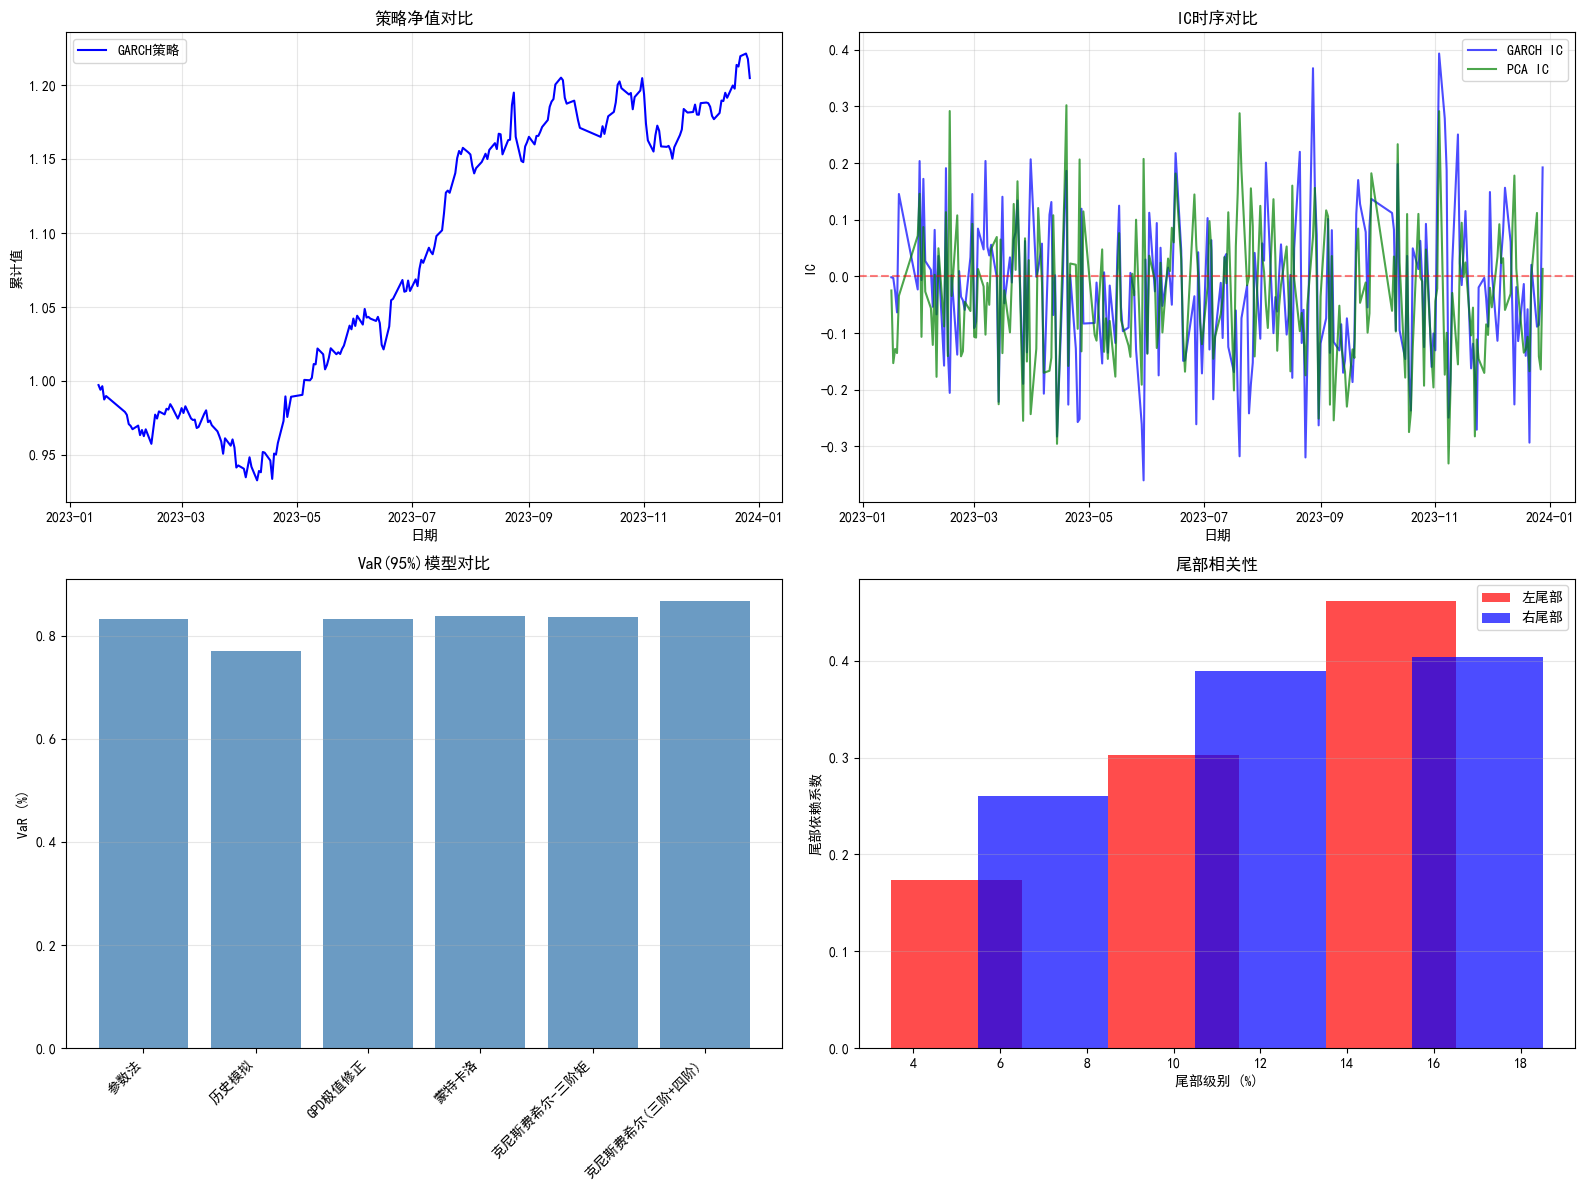

In [53]:
# 7. 最终汇总可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 策略净值对比
try:
    if 'strategy_df_plot' in locals() and 'strategy_cum' in strategy_df_plot.columns:
        axes[0, 0].plot(strategy_df_plot['date'], strategy_df_plot['strategy_cum'], label='GARCH策略', color='blue', linewidth=1.5)
    if 'pca_strategy_plot' in locals() and 'pca_cum' in pca_strategy_plot.columns:
        axes[0, 0].plot(pca_strategy_plot['date'], pca_strategy_plot['pca_cum'], label='PCA策略', color='green', linewidth=1.5)
        if 'hs300_cum' in pca_strategy_plot.columns:
            axes[0, 0].plot(pca_strategy_plot['date'], pca_strategy_plot['hs300_cum'], label='沪深300', color='orange', linewidth=1.5, alpha=0.7)
    axes[0, 0].set_title('策略净值对比', fontsize=12)
    axes[0, 0].set_xlabel('日期')
    axes[0, 0].set_ylabel('累计值')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
except Exception as e:
    axes[0, 0].text(0.5, 0.5, '策略净值数据未找到', ha='center', va='center', transform=axes[0, 0].transAxes)

# 2. IC对比
try:
    if 'ic_series' in locals() and 'pca_ic_series' in locals():
        ic_compare = pd.DataFrame({'GARCH IC': ic_series, 'PCA IC': pca_ic_series}).dropna()
        axes[0, 1].plot(ic_compare.index, ic_compare['GARCH IC'], label='GARCH IC', color='blue', alpha=0.7)
        axes[0, 1].plot(ic_compare.index, ic_compare['PCA IC'], label='PCA IC', color='green', alpha=0.7)
        axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[0, 1].set_title('IC时序对比', fontsize=12)
        axes[0, 1].set_xlabel('日期')
        axes[0, 1].set_ylabel('IC')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'IC数据未找到', ha='center', va='center', transform=axes[0, 1].transAxes)
except Exception as e:
    axes[0, 1].text(0.5, 0.5, 'IC对比图生成失败', ha='center', va='center', transform=axes[0, 1].transAxes)

# 3. VaR模型对比
try:
    if 'var_95' in locals() and 'methods' in locals():
        x = np.arange(len(methods))
        axes[1, 0].bar(x, [v*100 for v in var_95], color='steelblue', alpha=0.8)
        axes[1, 0].set_title('VaR(95%)模型对比', fontsize=12)
        axes[1, 0].set_ylabel('VaR (%)')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels(methods, rotation=45, ha='right')
        axes[1, 0].grid(True, alpha=0.3, axis='y')
    else:
        axes[1, 0].text(0.5, 0.5, 'VaR数据未找到', ha='center', va='center', transform=axes[1, 0].transAxes)
except Exception as e:
    axes[1, 0].text(0.5, 0.5, 'VaR对比图生成失败', ha='center', va='center', transform=axes[1, 0].transAxes)

# 4. 尾部相关性
try:
    if 'tail_df' in locals() and 'left_tail_dependence' in tail_df.columns:
        axes[1, 1].bar(tail_df['tail_level'] * 100, tail_df['left_tail_dependence'], width=3, label='左尾部', color='red', alpha=0.7)
        if 'right_tail_dependence' in tail_df.columns:
            axes[1, 1].bar(tail_df['tail_level'] * 100 + 2, tail_df['right_tail_dependence'], width=3, label='右尾部', color='blue', alpha=0.7)
        axes[1, 1].set_title('尾部相关性', fontsize=12)
        axes[1, 1].set_xlabel('尾部级别 (%)')
        axes[1, 1].set_ylabel('尾部依赖系数')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    else:
        axes[1, 1].text(0.5, 0.5, '尾部相关性数据未找到', ha='center', va='center', transform=axes[1, 1].transAxes)
except Exception as e:
    axes[1, 1].text(0.5, 0.5, '尾部相关性图生成失败', ha='center', va='center', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

In [51]:
print("\n" + "="*80)
print("量化策略全流程分析完成！")
print("="*80)
print("\n生成文件列表:")
print("  1. garch_factor_ic_analysis.png - GARCH因子IC分析图")
print("  2. garch_long_short_strategy.png - GARCH多空策略净值图")
print("  3. pca_analysis.png - PCA主成分分析图")
print("  4. pca_long_short_strategy.png - PCA多空策略净值图")
print("  5. copula_tail_dependence.png - Copula尾部相关性图")
print("  6. var_es_comparison.png - VaR/ES模型对比图")
print("  7. stress_test_results.png - 压力测试结果图")
print("  8. final_summary.png - 最终汇总对比图")
print("\n策略绩效汇总:")
print(f"  GARCH策略年化收益: {garch_metrics['annual_return']:.2%}, 夏普: {garch_metrics['sharpe']:.3f}")
print(f"  PCA策略年化收益: {pca_metrics['annual_return']:.2%}, 夏普: {pca_metrics['sharpe']:.3f}")
print(f"  沪深300年化收益: {hs300_metrics['annual_return']:.2%}, 夏普: {hs300_metrics['sharpe']:.3f}")


量化策略全流程分析完成！

生成文件列表:
  1. garch_factor_ic_analysis.png - GARCH因子IC分析图
  2. garch_long_short_strategy.png - GARCH多空策略净值图
  3. pca_analysis.png - PCA主成分分析图
  4. pca_long_short_strategy.png - PCA多空策略净值图
  5. copula_tail_dependence.png - Copula尾部相关性图
  6. var_es_comparison.png - VaR/ES模型对比图
  7. stress_test_results.png - 压力测试结果图
  8. final_summary.png - 最终汇总对比图

策略绩效汇总:
  GARCH策略年化收益: 20.93%, 夏普: 1.637
  PCA策略年化收益: 8.33%, 夏普: 0.636
  沪深300年化收益: -21.80%, 夏普: -1.870
